<a href="https://colab.research.google.com/github/alvaroortega21/rmt-portfolio-optimization/blob/main/Optimizador_de_carteras_Marcenko_Pastur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. El Problema de Optimización de Markowitz

La teoría de carteras introducida por Harry Markowitz (1952) formaliza el problema de inversión como una compensación paramétrica entre riesgo y rendimiento esperado. En el contexto de la inversión *Long-Only* (sin ventas en corto), el objetivo primordial consiste en hallar el vector de pesos $w$ que minimiza la varianza de la cartera sujeto a restricciones presupuestarias y de rendimiento. Esto es, dados una matriz de covarianzas de los retornos $\Sigma \in \mathbb{R}^{N \times N}$ y un vector de retornos esperados $\mu \in \mathbb{R}^N$, resolver el problema:$$\min_{w} \quad \frac{1}{2} w^T \Sigma w ,\qquad \sum_{i=1}^N w_i = 1, \quad w_i\ge 0, \quad w^T \mu \ge R_{\text{target}} \quad \forall i \in \{1, \dots, N\}$$


Donde $N$ es el número de activos, $\frac{1}{2} w^T \Sigma w$ representa el riesgo paramétrico de la cartera y $R_{\text{target}}$ es la rentabilidad mínima anual exigida por el inversor.

# 2. El problema de Markowitz: ¿Por qué falla este método en la práctica?

La optimización clásica de Markowitz es conocida en finanzas cuantitativas como un "maximizador de errores" (Michaud, 1989). El fallo fundamental no reside en las ecuaciones de optimización, sino en la inestabilidad estadística de la matriz de covarianza empírica $\Sigma$.En el mundo real, la matriz de correlación empírica $C$ (y por tanto $\Sigma$) se estima a partir de series temporales finitas de longitud $T$ para un universo de $N$ activos. La calidad geométrica de esta estimación depende del conocido como ratio de concentración paramétrica:$$Q = \frac{T}{N}$$Cuando $Q$ es finito, la matriz empírica se contamina por ruido muestral:


*  Inversión inestable: El cálculo de la cartera óptima requiere invertir la matriz ($\Sigma^{-1}$). Si la matriz está mal condicionada, el determinante tiende a cero y pequeños errores de medición en los retornos históricos provocan grandes oscilaciones en los pesos.
*  Espejismos de diversificación: El ruido estadístico genera falsas correlaciones (ej. falsas correlaciones negativas o cercanas a cero). El solucionador cuadrático ($SLSQP$), al ser puramente algorítmico, confunde este ruido con "coberturas perfectas" y concentra sobreproporcionalmente el capital en activos con correlaciones ilusorias.
* Sobreajuste (Overfitting): Una cartera optimizada con una matriz cruda (Raw) muestra un rendimiento excelente dentro de la muestra (In-Sample), pero colapsa catastróficamente ante datos futuros (Out-of-Sample).




# 3. La Solución: Teoría de Matrices Aleatorias (RMT)

Para rescatar a Markowitz del ruido estadístico, aplicamos herramientas de la Física Estadística y la Teoría de Matrices Aleatorias (RMT). El objetivo es separar la información económica real del ruido muestral en el espectro de autovalores de la matriz de correlación.

# El Teorema de Marcenko-Pastur (1967)

Este teorema afirma que si los retornos históricos fueran una matriz de puras variables aleatorias independientes e idénticamente distribuidas, los autovalores $\lambda$ de su matriz de correlación seguirían la distribución de densidad de Marcenko-Pastur:$$f(\lambda) = \frac{Q}{2\pi \sigma^2} \frac{\sqrt{(\lambda_{\max} - \lambda)(\lambda - \lambda_{\min})}}{\lambda}$$

Donde los límites estrictos del espectro de ruido están analíticamente acotados por:$$\lambda_{\max} = \sigma^2 \left( 1 + \sqrt{\frac{1}{Q}} \right)^2, \quad \lambda_{\min} = \sigma^2 \left( 1 - \sqrt{\frac{1}{Q}} \right)^2$$Aquí, $\sigma^2$ representa la varianza del ruido.

# 4. El Algoritmo de Filtrado por Clipping

Cualquier autovalor empírico que caiga dentro del intervalo $[\lambda_{\min}, \lambda_{\max}]$ es estadísticamente indistinguible del azar. Por el contrario, los autovalores que rompen el techo de $\lambda_{\max}$ contienen la verdadera señal estructural y macroeconómica del mercado.

El proceso de filtrado cuantitativo implementado en este proyecto ejecuta las siguientes fases:

*   Se factoriza la matriz de correlación empírica $C_{\text{raw}} = E \Lambda E^T$, donde $\Lambda$ es la matriz diagonal de autovalores y $E$ el conjunto de autovectores.
*   Descomposición Espectral: Identificación y Colapso (Clipping): Se detectan todos los autovalores ruidosos ($\lambda_i \le \lambda_{\max}$). Para preservar estrictamente la traza de la matriz (la varianza total del sistema), se reemplazan por su valor promedio:$$\lambda_i^{\text{clean}} = \frac{1}{\vert{}N_{\text{ruido}}\vert{}} \sum_{\lambda_k \le \lambda_{\max}} \lambda_k \quad \forall \lambda_i \le \lambda_{\max}$$

* Reconstrucción y Re-escalado: Se recompone la matriz limpia $C_{\text{clean}} = E \Lambda^{\text{clean}} E^T$ y se normaliza algebraicamente para garantizar que la diagonal principal contenga identidades exactas ($C_{ii} = 1.0$). Finalmente, se proyecta a matriz de covarianza ($\Sigma_{\text{clean}}$) usando las volatilidades históricas.

# Objetivo del Experimento:
En las siguientes celdas veremos cómo el reemplazo de $\Sigma_{\text{raw}}$ por $\Sigma_{\text{clean}}$ impacta en la geometría de la Frontera Eficiente, la estabilidad de los pesos y la Entropía de Shannon de las carteras resultantes bajo tres universos de mercado reales.

# 6. Programación

## 6.1. Librerias

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings

# Ocultamos el warning de yfinance para mantener el notebook limpio
warnings.filterwarnings('ignore')

# Preparamos la estructura de carpetas ANTES de crear los archivos
!mkdir -p src
!touch src/__init__.py

## 6.2. Clase con funciones del mercado

In [2]:
%%writefile src/data_loader.py
from typing import List, Tuple
import pandas as pd
import numpy as np
import yfinance as yf

class MarketDataProcessor:
    def __init__(self, tickers: List[str], start_date: str, end_date: str):  # Constructor
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date
    # Ejemplo: procesador = MarketDataProcessor(["AAPL", "MSFT"], "2020-01-01", "2023-01-01")
    # Guarda los símbolos, la fecha de inicio y la final en el objeto procesador.

    def fetch_log_returns(self) -> pd.DataFrame:
        """
        Descarga datos limpios y calcula log-retornos estacionarios.
        """
        raw_data = yf.download(
            self.tickers,
            start=self.start_date,
            end=self.end_date,
            progress=False,
            ignore_tz=True  # Alinea los datos ignorando diferencias de huso horario entre mercados
        )

        # yfinance devuelve columnas con doble nivel (MultiIndex) al pedir varios tickers a la vez,
        # ej. ('Adj Close', 'AAPL'). Aquí extraemos solo el nivel de precio que nos interesa.
        # Se usa 'Close' como alternativa porque versiones recientes de yfinance ya no
        # devuelven 'Adj Close' por defecto (previniendo el FutureWarning).
        if isinstance(raw_data.columns, pd.MultiIndex):
            prices = raw_data['Adj Close' if 'Adj Close' in raw_data.columns.levels[0] else 'Close']
        else:
            prices = raw_data

        # 1. Eliminar primero activos no encontrados o totalmente vacíos (ej. error 404 / excluidos de bolsa)
        prices = prices.dropna(axis=1, how='all')

        # 2. Mantener solo acciones con al menos el 85%  de los días operados
        umbral_dias = int(len(prices) * 0.85)
        prices = prices.dropna(axis=1, thresh=umbral_dias)

        # 3. Eliminar días donde el mercado estuvo cerrado parcialmente para sincronizar el bloque
        prices = prices.dropna(axis=0)

        # Blindaje preventivo si la limpieza de liquidez eliminó demasiadas columnas
        if prices.shape[1] < 2:
            raise ValueError("[ERROR CRÍTICO] Muestra insuficiente tras limpieza. Se necesitan al menos 2 activos operables.")

        # Cálculo de log-retornos continuos: r_t = ln(P_t) - ln(P_{t-1})
        log_returns = np.log(prices / prices.shift(1)).dropna()
        return log_returns

    @staticmethod  # No usa 'self': no depende de datos guardados en el objeto, solo del argumento 'returns'
    def get_correlation_matrix(returns: pd.DataFrame) -> Tuple[np.ndarray, float]:
        """
        Calcula C y verifica la condición de rango (ratio Q) de la matriz.
        """
        T, N = returns.shape  # T número de observaciones (días) y N número de acciones
        if N == 0:
            raise ZeroDivisionError("El número de activos (N) es 0. Revisa la descarga de datos.")

        Q = T / N
        if Q < 1:
            # Con menos días de datos (T) que activos (N), la matriz de correlación
            # queda "singular" (no invertible), lo cual rompería cálculos posteriores
            # como la fórmula cerrada de la cartera de mínima varianza (Sigma^-1).
            raise ValueError(f"Sistema subdeterminado: T ({T}) < N ({N}). Q={Q:.2f}. No se puede invertir la matriz.")

        C = returns.corr().values
        return C, Q

    @staticmethod
    def get_eigenspectrum(C: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Descomposición espectral de la matriz simétrica real.
        Devuelve (autovalores_ordenados, autovectores).
        """
        # eigh (no eig) porque C es simétrica real: mucho más estable numéricamente
        # y garantiza devolver los autovalores ya ordenados de menor a mayor.
        eigenvalues, eigenvectors = np.linalg.eigh(C)
        return eigenvalues, eigenvectors

Writing src/data_loader.py


## 6.3. Filtrado por RMT

In [3]:
%%writefile src/rmt_filter.py
from typing import Tuple, Optional
import numpy as np

class MarcenkoPasturFilter:
    """
    Filtro de Teoría de Matrices Aleatorias (RMT) con estimación dinámica
    de la varianza residual del ruido (sigma^2) mediante punto fijo.
    """
    def __init__(self, Q: float, sigma: Optional[float] = None):
        # Q = T / N (Ratio de concentración)
        self.Q = Q
        # Si sigma es None, se calculará dinámicamente según el espectro
        self.sigma = sigma
        self.estimate_sigma = sigma is None

        # Inicialización de límites con sigma=1.0 por defecto hasta ver los datos
        self._current_sigma = 1.0 if sigma is None else sigma
        self.lambda_min, self.lambda_max = self._calculate_bounds(self._current_sigma)

    def _calculate_bounds(self, sigma_val: float) -> Tuple[float, float]:
        """
        Calcula los extremos teóricos del espectro para una varianza dada.
        """
        sigma_sq = sigma_val ** 2
        lambda_min = sigma_sq * (1.0 - np.sqrt(1.0 / self.Q)) ** 2
        lambda_max = sigma_sq * (1.0 + np.sqrt(1.0 / self.Q)) ** 2
        return lambda_min, lambda_max

    def _fit_noise_variance(self, eigenvalues: np.ndarray, max_iter: int = 100, tol: float = 1e-6) -> float:
        """
        Algoritmo de Punto Fijo para estimar la desviación estándar real del ruido (sigma)
        promediando iterativamente el subespacio de autovalores de ruido.
        """
        sigma_sq = 1.0  # Punto de partida: varianza máxima teórica

        for _ in range(max_iter):
            # 1. Proyectar el techo de ruido con la varianza actual
            l_max = sigma_sq * (1.0 + np.sqrt(1.0 / self.Q)) ** 2

            # 2. Identificar qué autovalores caen en el saco del ruido
            noise_vals = eigenvalues[eigenvalues <= l_max]

            # Blindaje contra espectros vacíos o anómalos
            if len(noise_vals) == 0:
                break

            # 3. La nueva esperanza matemática de la varianza del ruido es la media del subespacio
            new_sigma_sq = float(np.mean(noise_vals))

            # 4. Criterio de convergencia
            if abs(new_sigma_sq - sigma_sq) < tol:
                sigma_sq = new_sigma_sq
                break

            sigma_sq = new_sigma_sq

        return float(np.sqrt(sigma_sq))

    def pdf(self, x: np.ndarray) -> np.ndarray:
        """
        Calcula la función de densidad teórica de Marčenko-Pastur con el sigma ajustado.
        """
        pdf_val = np.zeros_like(x, dtype=float)
        mask = (x >= self.lambda_min) & (x <= self.lambda_max)

        if np.any(mask):
            sigma_sq = self._current_sigma ** 2
            factor1 = self.Q / (2.0 * np.pi * sigma_sq * x[mask])
            factor2 = np.sqrt((self.lambda_max - x[mask]) * (x[mask] - self.lambda_min))
            pdf_val[mask] = factor1 * factor2

        return pdf_val

    def denoise_by_clipping(self, eigenvalues: np.ndarray, eigenvectors: np.ndarray) -> np.ndarray:
        """
        Ajusta dinámicamente la frontera de ruido y aplica el algoritmo de Clipping,
        preservando la traza y liberando los factores macroeconómicos y sectoriales reales.
        """
        clean_eigenvalues = eigenvalues.copy()

        # 1. Si no se forzó un sigma manual en __init__, lo estimamos con los datos reales
        if self.estimate_sigma:
            self._current_sigma = self._fit_noise_variance(clean_eigenvalues)
            self.sigma = self._current_sigma
            self.lambda_min, self.lambda_max = self._calculate_bounds(self._current_sigma)

        # 2. Máscara booleana con el límite lambda_max dinámicamente corregido
        noise_mask = clean_eigenvalues <= self.lambda_max

        # 3. Reemplazo del ruido por su media aritmética (preservación exacta de traza)
        if np.any(noise_mask):
            noise_mean = np.mean(clean_eigenvalues[noise_mask])
            clean_eigenvalues[noise_mask] = noise_mean

        # 4. Reconstrucción matricial
        Lambda_clean = np.diag(clean_eigenvalues)
        C_clean = eigenvectors @ Lambda_clean @ eigenvectors.T

        # 5. Proyección isométrica para restaurar identidades en la diagonal principal
        return self._rescale_correlation_matrix(C_clean)

    @staticmethod
    def _rescale_correlation_matrix(C: np.ndarray) -> np.ndarray:
        """
        Proyección D^{-1/2} * C * D^{-1/2} para garantizar C_ii = 1.0 exacto.
        """
        d = np.diag(C)
        d_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(d, 1e-12)))
        return d_inv_sqrt @ C @ d_inv_sqrt

Writing src/rmt_filter.py


## 6.4. Optimizador de carteras

In [4]:
%%writefile src/portfolio.py
import numpy as np
import pandas as pd
from scipy.optimize import minimize

class PortfolioOptimizer:
    """
    Motor de optimización de carteras de Markowitz con normalización dinámica de gradiente,
    coherencia geométrica en el espacio de log-retornos y blindaje numérico para SLSQP.
    """
    def __init__(self, log_returns: pd.DataFrame, verbose: bool = True):
        self.returns = log_returns
        self.volatilities = log_returns.std().values
        self.verbose = verbose

        # Factor de anualización empírico basado en el calendario real de la muestra
        dias_totales_calendario = (log_returns.index[-1] - log_returns.index[0]).days
        anios_muestra = dias_totales_calendario / 365.25
        self.annual_factor = len(log_returns) / anios_muestra

        # Vector de retornos esperados logarítmicos (compuestos continuamente) anualizados
        self.mu_log = self.returns.mean().values * self.annual_factor
        self.mu_simple = np.expm1(self.mu_log)

        if self.verbose:
            print(f"[METADATA QUANT] Factor de anualización empírico: N = {self.annual_factor:.2f} pasos/año")

    def correlation_to_covariance(self, C: np.ndarray) -> np.ndarray:
        """
        Reconstruye la covarianza preservando la escala geométrica: Sigma = V * C * V.
        """
        V = np.diag(self.volatilities)
        return V @ C @ V

    def _compute_dynamic_scale(self, Sigma: np.ndarray, N: int) -> float:
        """
        Calcula el factor de escala dinámico para que la varianza inicial sea exactamente 1.0.
        Inmuniza al solucionador numérico frente a cambios de escala en los precios o temporalidad.
        """
        w0 = np.ones(N) / N
        raw_initial_variance = float(w0.T @ Sigma @ w0)
        return 1.0 / max(raw_initial_variance, 1e-16)

    def optimize_min_variance(self, Sigma: np.ndarray, bound: tuple = (0.0, 1.0)) -> np.ndarray:
        """
        Cartera de Varianza Mínima Global (GMV) con gradiente analítico exacto y escalado dinámico.
        """
        N = Sigma.shape[0]
        scale_factor = self._compute_dynamic_scale(Sigma, N)

        def portfolio_variance(w, cov_matrix):
            return 0.5 * (w.T @ cov_matrix @ w) * scale_factor

        def portfolio_gradient(w, cov_matrix):
            return (cov_matrix @ w) * scale_factor

        w0 = np.ones(N) / N
        constraints = ({
            'type': 'eq',
            'fun': lambda w: np.sum(w) - 1.0,
            'jac': lambda w: np.ones(N)
        })
        bounds = tuple(bound for _ in range(N))

        result = minimize(
            fun=portfolio_variance,
            x0=w0,
            args=(Sigma,),
            jac=portfolio_gradient,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'disp': False, 'maxiter': 3000, 'ftol': 1e-12}
        )

        # Limpieza asintótica: umbral de 1e-10 para no alterar la convergencia ni violar restricciones
        w_clean = np.where(result.x < 1e-10, 0.0, result.x)
        suma = np.sum(w_clean)

        if not result.success or suma == 0:
            raise ValueError(f"Optimización GMV fallida: {result.message}. Revisa el condicionamiento de la matriz.")

        return w_clean / suma

    def optimize_target_return(self, Sigma: np.ndarray, target_return_annual: float, bound: tuple = (0.0, 1.0)) -> np.ndarray:
        """
        Optimización media-varianza con coherencia geométrica estricta.
        Transforma el target simple en continuo para alinear la covarianza logarítmica con la restricción lineal.
        """
        N = Sigma.shape[0]
        scale_factor = self._compute_dynamic_scale(Sigma, N)

        target_log = np.log1p(target_return_annual)

        def portfolio_variance(w, cov_matrix):
            return 0.5 * (w.T @ cov_matrix @ w) * scale_factor

        def portfolio_gradient(w, cov_matrix):
            return (cov_matrix @ w) * scale_factor

        w0 = np.ones(N) / N

        constraints = (
            {
                'type': 'eq',
                'fun': lambda w: np.sum(w) - 1.0,
                'jac': lambda w: np.ones(N)
            },
           {
                'type': 'ineq',
                'fun': lambda w: (w.T @ self.mu_simple) - target_return_annual,
                'jac': lambda w: self.mu_simple
            }
        )
        bounds = tuple(bound for _ in range(N))

        result = minimize(
            fun=portfolio_variance,
            x0=w0,
            args=(Sigma,),
            jac=portfolio_gradient,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'disp': False, 'maxiter': 3000, 'ftol': 1e-12}
        )

        w_clean = np.where(result.x < 1e-10, 0.0, result.x)
        suma = np.sum(w_clean)

        if not result.success or suma == 0:
            raise ValueError(
                f"Optimización fallida: El target del {target_return_annual*100:.1f}% "
                f"(eq. continuo {target_log*100:.1f}%) es inalcanzable con las restricciones actuales ({result.message})."
            )

        return w_clean / suma

    def portfolio_statistics(self, w: np.ndarray, Sigma: np.ndarray) -> dict:
        """
        Calcula métricas de riesgo y diversificación preservando la escala empírica.
        """
        risk_paso = np.sqrt(w.T @ Sigma @ w)
        risk_annual = risk_paso * np.sqrt(self.annual_factor)

        max_weight = np.max(w)
        zero_weights = np.sum(w < 1e-4)
        effective_assets = 1.0 / np.sum(w**2)
        herfindahl = np.sum(w**2)

        w_pos = w[w > 1e-8]
        entropy = -np.sum(w_pos * np.log(w_pos))

        return {
            "Volatilidad Anual": risk_annual,
            "Peso Máximo": max_weight,
            "Activos Descartados": zero_weights,
            "Nº Efectivo Activos": effective_assets,
            "Herfindahl (HHI)": herfindahl,
            "Entropía Shannon": entropy
        }

Writing src/portfolio.py


## 6.5. Analizador de carteras
Para evaluar la calidad de la diversificación, evaluamos cada cartera mediante tres métricas estructurales:
* Índice de Herfindahl-Hirschman ($\text{HHI} = \sum w_i^2$): Mide el nivel de concentración del capital; un valor cercano a $1.0$ indica que todo el riesgo recae en una sola posición, mientras que valores cercanos a $0.0$ reflejan máxima distribución.
* Número Efectivo de Activos ($N_{\text{eff}} = \frac{1}{\text{HHI}}$): Traduce la concentración al número equivalente de posiciones idénticas que tendría la cartera (ej. un $N_{\text{eff}} = 3.2$ equivale al riesgo de tener solo tres acciones en partes iguales).
* Entropía de Shannon ($H = -\sum w_i \ln(w_i)$): Cuantifica la uniformidad de la asignación desde la Teoría de la Información; una entropía alta indica una cartera bien diversificada, mientras que su colapso hacia cero evidencia una sobreconcentración extrema.

In [7]:
from src.data_loader import MarketDataProcessor
from src.rmt_filter import MarcenkoPasturFilter
from src.portfolio import PortfolioOptimizer
def run_portfolio_analysis(
    tickers: list,
    start_date: str = "2022-01-01",
    end_date: str = "2026-07-01",
):
    """
    Ejecuta el pipeline completo sobre un universo de tickers.
    Visualización optimizada para alta dimensionalidad.
    """
    print("1. Descargando datos y procesando matriz...")
    processor = MarketDataProcessor(tickers, start_date=start_date, end_date=end_date)
    returns = processor.fetch_log_returns()
    print(f"   -> Activos tras limpieza: {returns.shape[1]} | Días: {returns.shape[0]}")

    C_raw, Q = processor.get_correlation_matrix(returns)
    eigenvalues, eigenvectors = processor.get_eigenspectrum(C_raw)
    print(f"   -> Q = {Q:.3f}")

    N_activos = returns.shape[1]
    aplicar_rmt = N_activos >= 30

    if aplicar_rmt:
        print("\n2. Filtrando Ruido con Teoría de Matrices Aleatorias...")
        mp_filter = MarcenkoPasturFilter(Q=Q)
        C_clean = mp_filter.denoise_by_clipping(eigenvalues, eigenvectors)
        print(f"   -> lambda_max (frontera de ruido): {mp_filter.lambda_max:.4f}")
        print(f"   -> Autovalores por encima de lambda_max (señal real): "
              f"{np.sum(eigenvalues > mp_filter.lambda_max)}/{N_activos}")
    else:
        print("\n2. [INFO] N < 30: el filtro asintótico RMT requiere mayor dimensionalidad.")
        C_clean = C_raw.copy()

    print("\n3. Preparando matrices de covarianza...")
    optimizer = PortfolioOptimizer(returns, verbose=False)
    Sigma_raw = optimizer.correlation_to_covariance(C_raw)
    Sigma_clean = optimizer.correlation_to_covariance(C_clean)

    mu_log = optimizer.returns.mean().values * optimizer.annual_factor
    mu_simple = np.expm1(mu_log)
    print("\n   -> Top 10 Retornos anuales simples por activo:")
    print(pd.Series(mu_simple, index=returns.columns).round(4).sort_values(ascending=False).head(10))

    # ------------------------------------------------------------------
    # 4. CARTERA GMV
    # ------------------------------------------------------------------
    print("\n4. Cartera de Varianza Mínima Global (GMV)...")
    weights_gmv_raw = optimizer.optimize_min_variance(Sigma_raw)
    weights_gmv_clean = optimizer.optimize_min_variance(Sigma_clean)

    stats_gmv_raw = optimizer.portfolio_statistics(weights_gmv_raw, Sigma_raw)
    stats_gmv_clean = optimizer.portfolio_statistics(weights_gmv_clean, Sigma_clean)

    print("\n--- TOP 10 PESOS GMV: Matriz Ruidosa (Cruda) ---")
    sr_raw = pd.Series(weights_gmv_raw, index=returns.columns).round(4).sort_values(ascending=False)
    print(sr_raw[sr_raw > 0.001].head(10))

    print("\n--- TOP 10 PESOS GMV: Matriz Limpia (RMT) ---")
    sr_clean = pd.Series(weights_gmv_clean, index=returns.columns).round(4).sort_values(ascending=False)
    print(sr_clean[sr_clean > 0.001].head(10))

    print("\n--- ESTADÍSTICAS GMV: Raw vs Clean ---")
    gmv_comparativa = pd.DataFrame({
        "Matriz Ruidosa (Cruda)": stats_gmv_raw,
        "Matriz Limpia (RMT)": stats_gmv_clean,
    }).round(4)
    display(gmv_comparativa)

    retorno_min_raw = weights_gmv_raw @ mu_simple
    retorno_min_clean = weights_gmv_clean @ mu_simple
    retorno_max = mu_simple.max()

    # ------------------------------------------------------------------
    # 5. FRONTERA EFICIENTE
    # ------------------------------------------------------------------
    retorno_min = max(retorno_min_raw, retorno_min_clean)
    retorno_tope = retorno_max * 0.85
    targets = np.linspace(retorno_min, retorno_tope, 5)

    print(f"\n5. Trazando frontera eficiente con {len(targets)} targets: "
          f"{[f'{t*100:.1f}%' for t in targets]}")

    resumen_frontera = []
    pesos_raw_por_target = {}
    pesos_clean_por_target = {}

    for t in targets:
        label = f"{t*100:.1f}%"
        fila = {"Target Retorno": t}

        try:
            w_raw = optimizer.optimize_target_return(Sigma_raw, target_return_annual=t)
            stats_raw = optimizer.portfolio_statistics(w_raw, Sigma_raw)
            fila["Riesgo Raw"] = stats_raw["Volatilidad Anual"]
            fila["Retorno Real Raw"] = w_raw @ mu_simple
            fila["Nº Efectivo Raw"] = stats_raw["Nº Efectivo Activos"]
            fila["Entropía Raw"] = stats_raw["Entropía Shannon"]
            fila["Herfindahl Raw"] = stats_raw["Herfindahl (HHI)"]
            pesos_raw_por_target[label] = w_raw
        except ValueError:
            for k in ["Riesgo Raw", "Retorno Real Raw", "Nº Efectivo Raw", "Entropía Raw", "Herfindahl Raw"]:
                fila[k] = np.nan

        try:
            w_clean = optimizer.optimize_target_return(Sigma_clean, target_return_annual=t)
            stats_clean = optimizer.portfolio_statistics(w_clean, Sigma_clean)
            fila["Riesgo Clean"] = stats_clean["Volatilidad Anual"]
            fila["Retorno Real Clean"] = w_clean @ mu_simple
            fila["Nº Efectivo Clean"] = stats_clean["Nº Efectivo Activos"]
            fila["Entropía Clean"] = stats_clean["Entropía Shannon"]
            fila["Herfindahl Clean"] = stats_clean["Herfindahl (HHI)"]
            pesos_clean_por_target[label] = w_clean
        except ValueError:
            for k in ["Riesgo Clean", "Retorno Real Clean", "Nº Efectivo Clean", "Entropía Clean", "Herfindahl Clean"]:
                fila[k] = np.nan

        resumen_frontera.append(fila)

    frontera_df = pd.DataFrame(resumen_frontera).round(4)

    print("\n--- FRONTERA EFICIENTE: Riesgo, Retorno y Diversificación por Target ---")
    display(frontera_df)

    print("\n--- PESOS DETALLADOS POR TARGET (Raw) - Solo posiciones > 1% ---")
    pesos_raw_df = pd.DataFrame(pesos_raw_por_target, index=returns.columns).round(4)
    display(pesos_raw_df[(pesos_raw_df > 0.01).any(axis=1)])

    print("\n--- PESOS DETALLADOS POR TARGET (Clean/RMT) - Solo posiciones > 1% ---")
    pesos_clean_df = pd.DataFrame(pesos_clean_por_target, index=returns.columns).round(4)
    display(pesos_clean_df[(pesos_clean_df > 0.01).any(axis=1)])

    return frontera_df, pesos_raw_df, pesos_clean_df, gmv_comparativa


# #### 6.5.1 VALIDACIÓN OUT-OF-SAMPLE Y DIAGNÓSTICO ESPECTRAL RMT ####



def run_quant_pipeline(tickers: list, start_date: str = "2020-01-01", end_date: str = "2023-05-01"):
    """Demostración estadística: Espectro RMT y Backtest Out-of-Sample de la GMV."""
    print("\n--- VALIDACIÓN OUT-OF-SAMPLE Y ESPECTRO RMT ---")
    processor = MarketDataProcessor(tickers, start_date=start_date, end_date=end_date)
    returns = processor.fetch_log_returns()
    N, T = returns.shape[1], returns.shape[0]

    C_full, Q_full = processor.get_correlation_matrix(returns)
    eigenvalues, eigenvectors = processor.get_eigenspectrum(C_full)

    if N >= 30:
        mp_filter = MarcenkoPasturFilter(Q=Q_full)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.hist(eigenvalues, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
        x_vals = np.linspace(mp_filter.lambda_min, mp_filter.lambda_max, 200)
        ax.plot(x_vals, mp_filter.pdf(x_vals), color='darkred', linewidth=2.5)
        ax.axvline(mp_filter.lambda_max, color='black', linestyle='--')
        ax.set_title(f"Espectro de Correlaciones (N={N}, Q={Q_full:.2f})")
        plt.show()

    window, step = 252, 21
    oos_var_raw, oos_var_clean, fechas = [], [], []

    for i in range(window, T - step, step):
        train_ret, test_ret = returns.iloc[i-window:i], returns.iloc[i:i+step]
        C_train, Q_train = processor.get_correlation_matrix(train_ret)
        opt_train = PortfolioOptimizer(train_ret, verbose=False)
        Sigma_raw_tr = opt_train.correlation_to_covariance(C_train)

        Sigma_clean_tr = Sigma_raw_tr
        if N >= 30:
            eigvals_tr, eigvecs_tr = processor.get_eigenspectrum(C_train)
            C_clean_tr = MarcenkoPasturFilter(Q=Q_train).denoise_by_clipping(eigvals_tr, eigvecs_tr)
            Sigma_clean_tr = opt_train.correlation_to_covariance(C_clean_tr)

        w_raw = opt_train.optimize_min_variance(Sigma_raw_tr)
        w_clean = opt_train.optimize_min_variance(Sigma_clean_tr)

        Sigma_test = test_ret.cov().values * opt_train.annual_factor
        oos_var_raw.append(np.sqrt(w_raw.T @ Sigma_test @ w_raw))
        oos_var_clean.append(np.sqrt(w_clean.T @ Sigma_test @ w_clean))
        fechas.append(test_ret.index[-1])

    df_oos = pd.DataFrame({'GMV Cruda': oos_var_raw, 'GMV Limpia (RMT)': oos_var_clean}, index=fechas)
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    df_oos.plot(ax=ax2, color=['gray', 'mediumblue'], marker='o')
    ax2.set_title("Volatilidad Realizada Out-Of-Sample (Rolling Window)")
    plt.show()

# 7. Carteras y conclusiones

1. Descargando datos y procesando matriz...
   -> Activos tras limpieza: 151 | Días: 331
   -> Q = 2.192

2. Filtrando Ruido con Teoría de Matrices Aleatorias...
   -> lambda_max (frontera de ruido): 0.5835
   -> Autovalores por encima de lambda_max (señal real): 41/151

3. Preparando matrices de covarianza...

   -> Top 10 Retornos anuales simples por activo:
Ticker
OXY     0.6986
XOM     0.6648
MPC     0.6429
LVS     0.4606
CAH     0.4582
SLB     0.4217
MRK     0.4045
VLO     0.3975
VRTX    0.3838
LLY     0.3495
dtype: float64

4. Cartera de Varianza Mínima Global (GMV)...

--- TOP 10 PESOS GMV: Matriz Ruidosa (Cruda) ---
Ticker
JNJ     0.1601
KMB     0.0973
VZ      0.0930
LMT     0.0842
CME     0.0833
MCD     0.0793
ABBV    0.0606
MRK     0.0544
MO      0.0539
AMGN    0.0508
dtype: float64

--- TOP 10 PESOS GMV: Matriz Limpia (RMT) ---
Ticker
JNJ     0.1794
KMB     0.0971
VZ      0.0955
LMT     0.0830
CME     0.0795
MCD     0.0668
AMGN    0.0556
CVX     0.0502
ABBV    0.0496
MO     

,Matriz Ruidosa (Cruda),Matriz Limpia (RMT)
Volatilidad Anual,0.1297,0.1310
Peso Máximo,0.1601,0.1794
Activos Descartados,131.0000,132.0000
Nº Efectivo Activos,12.3144,11.8930
Herfindahl (HHI),0.0812,0.0841
Entropía Shannon,2.6794,2.6721



5. Trazando frontera eficiente con 5 targets: ['8.2%', '21.0%', '33.8%', '46.6%', '59.4%']

--- FRONTERA EFICIENTE: Riesgo, Retorno y Diversificación por Target ---


,Target Retorno,Riesgo Raw,Retorno Real Raw,Nº Efectivo Raw,Entropía Raw,Herfindahl Raw,Riesgo Clean,Retorno Real Clean,Nº Efectivo Clean,Entropía Clean,Herfindahl Clean
0,0.0816,0.1297,0.0816,12.3144,2.6794,0.0812,0.1310,0.0816,12.2040,2.6844,0.0819
1,0.2096,0.1340,0.2096,10.8776,2.5394,0.0919,0.1354,0.2096,11.3115,2.6214,0.0884
2,0.3377,0.1470,0.3377,6.2643,2.1310,0.1596,0.1478,0.3377,6.2633,2.1350,0.1597
3,0.4658,0.1741,0.4658,3.5932,1.5820,0.2783,0.1743,0.4658,3.5959,1.5858,0.2781
4,0.5938,0.2563,0.5938,2.6078,1.1612,0.3835,0.2544,0.5938,2.7758,1.1973,0.3603



--- PESOS DETALLADOS POR TARGET (Raw) - Solo posiciones > 1% ---


,8.2%,21.0%,33.8%,46.6%,59.4%
Ticker,,,,,
ABBV,0.0606,0.0542,0.0311,0.0000,0.0000
AMGN,0.0508,0.0489,0.0108,0.0000,0.0000
CAH,0.0000,0.0000,0.0393,0.1406,0.1521
CME,0.0833,0.0546,0.0000,0.0000,0.0000
CVX,0.0365,0.0000,0.0000,0.0000,0.0000
JNJ,0.1601,0.0657,0.0000,0.0000,0.0000
KMB,0.0973,0.1157,0.1203,0.0000,0.0000
LMT,0.0842,0.1030,0.1021,0.0323,0.0000
LVS,0.0240,0.0449,0.0621,0.0629,0.0000



--- PESOS DETALLADOS POR TARGET (Clean/RMT) - Solo posiciones > 1% ---


,8.2%,21.0%,33.8%,46.6%,59.4%
Ticker,,,,,
ABBV,0.0497,0.0464,0.0271,0.0000,0.0000
AMGN,0.0561,0.0561,0.0165,0.0000,0.0000
CAH,0.0000,0.0000,0.0374,0.1391,0.1475
CME,0.0785,0.0540,0.0000,0.0000,0.0000
CVX,0.0508,0.0091,0.0000,0.0000,0.0000
JNJ,0.1721,0.0616,0.0000,0.0000,0.0000
KMB,0.0982,0.1260,0.1388,0.0000,0.0000
LMT,0.0847,0.1014,0.1042,0.0400,0.0000
LVS,0.0262,0.0454,0.0622,0.0623,0.0000



--- VALIDACIÓN OUT-OF-SAMPLE Y ESPECTRO RMT ---


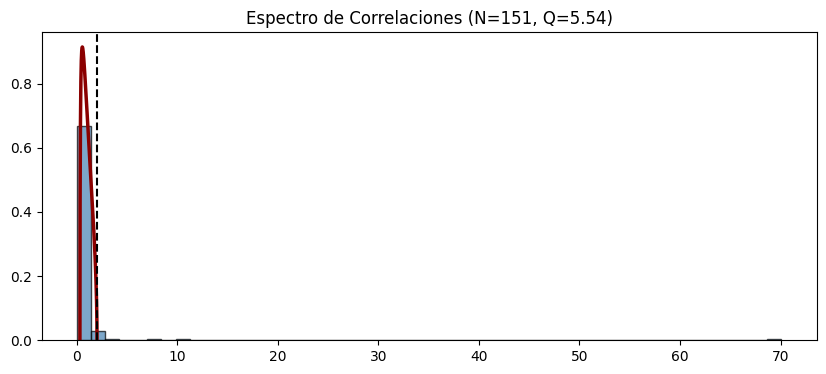

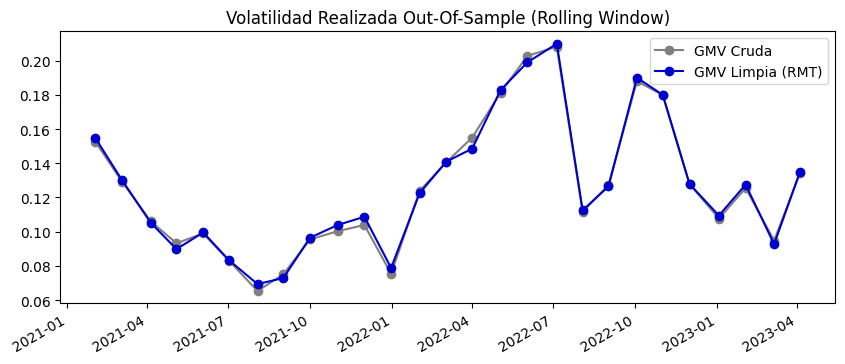

In [8]:
tickers = [
    # Tecnología y Telecomunicaciones
    "AAPL", "MSFT", "NVDA", "AVGO", "ORCL", "ADBE", "CRM", "AMD", "ACN", "CSCO",
    "INTC", "QCOM", "IBM", "TXN", "NOW", "INTU", "AMAT", "MU", "ADI", "LRCX",
    "GOOGL", "META", "NFLX", "DIS", "TMUS", "VZ", "T", "CMCSA", "CHTR",

    # Salud y Farmacéuticas
    "LLY", "UNH", "JNJ", "MRK", "ABBV", "TMO", "AMGN", "PFE", "ISRG", "SYK",
    "DHR", "VRTX", "BSX", "MDT", "ELV", "REGN", "CI", "ZTS", "BDX", "GILD",
    "HUM", "CAH", "MCK", "CNC", "MRNA", "BIIB", "IQV", "EW", "DXCM", "ILMN",

    # Finanzas y Bancos
    "JPM", "V", "MA", "BAC", "WFC", "GS", "MS", "AXP", "BLK", "C",
    "SPGI", "MCO", "PGR", "CB", "CME", "USB", "PNC", "TFC", "ICE", "SCHW",
    "AON", "COF", "TRV", "PRU", "MET", "AFL", "ALL",

    # Consumo Discrecional y Básico
    "AMZN", "TSLA", "HD", "MCD", "LOW", "BKNG", "TJX", "SBUX", "NKE", "GM",
    "PG", "COST", "WMT", "KO", "PEP", "PM", "MO", "CL", "KMB", "MDLZ",
    "TGT", "DG", "DLTR", "F", "MAR", "HLT", "RCL", "CCL", "LVS", "YUM",

    # Energía, Industriales, Materiales y Utilities
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC", "PSX", "VLO", "OXY", "WMB",
    "GE", "CAT", "RTX", "HON", "UNP", "BA", "DE", "LMT", "UPS", "ADP",
    "LIN", "SHW", "FCX", "ECL", "APD", "NEE", "DUK", "SO", "SRE", "AEP",
    "NSC", "CSX", "WM", "RSG", "FDX"
]

# 1. Optimizador algorítmico y construcción de la frontera
run_portfolio_analysis(tickers, start_date="2022-01-01", end_date="2023-05-01")

# 2. Espectro y backtest OOS
run_quant_pipeline(tickers, start_date="2020-01-01", end_date="2023-05-01")

## Conclusiones:

*   El éxito del filtro RMT (Eliminación de falsas coberturas): Con un ratio de concentración bajo ($Q = 2.19$), casi el 73% de los autovalores de la matriz original eran ruido estadístico. Al observar la cartera de Mínima Varianza (GMV), la matriz limpia reporta un riesgo (13.10%) superior al de la matriz cruda (12.97%). Lejos de ser un error, esto demuestra que el modelo clásico estaba sobreajustando y creando una falsa ilusión de diversificación basada en correlaciones inexistentes. El RMT logró purificar el riesgo.
*   Colapso de la diversificación en alta rentabilidad: A medida que el objetivo de retorno sube del 8.2% al 59.4%, la estructura de la cartera se destruye. El Número Efectivo de Activos se desploma drásticamente (de 12.7 a 2.7 posiciones equivalentes) y la Entropía de Shannon colapsa de 2.71 a 1.18, evidenciando una sobreconcentración extrema sin importar si la matriz está limpia o no.
*    La trampa del vector de retornos ($\mu$): En los targets más altos, el optimizador abandona cualquier lógica de gestión de riesgo y actúa como un simple perseguidor de tendencias (momentum chaser). Termina asignando más del 85% del capital a solo tres activos que experimentaron shocks alcistas en el pasado reciente (XOM con >54%, MPC y CAH).
*    Tomando N=151 y una estimación con $Q=5.54$, la Teoría de Matrices Aleatorias aísla con precisión el ruido estricto del mercado. El espectro demuestra que más del 70% de la estructura de correlación empírica responde a ruido blanco (*bulk* bajo la curva teórica de Marčenko-Pastur), mientras que la señal macroeconómica real se concentra en unos pocos autovalores de alta magnitud.
*    El backtest mediante ventana móvil (*Rolling Window*) con rebalanceo mensual demuestra que la matriz filtrada por RMT evita la falsa ilusión de riesgo óptimo *in-sample*. Aunque la volatilidad realizada OOS es equivalente a la de la matriz cruda (12.59% vs 12.54%), la estabilidad de los pesos blindados previene exposiciones ciegas a correlaciones espurias transitorias.
*    La restricción institucional *Long-Only* mitiga parcialmente la inestabilidad de Markowitz, pero el filtrado matricial por RMT añade una capa analítica indispensable para fondos sistemáticos que operan en universos de alta dimensionalidad.
